#### Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np

#### Read in data

In [3]:
survey = pd.read_csv("data/PingPongFormResponses.csv")

In [4]:
survey.head(5)

,Timestamp,"How many times have you used PingPong, approximately?",Why have you chatted with PingPong less than 5 times?,"Would you use PingPong more if it were different? \n\nIf not, why not? If yes, what would need to change about PingPong for you to use it more?","If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM?","Please elaborate on your response to the previous question. \n\nIf you prefer one LLM over another, why? If you are indifferent, why?","If course staff were not available, what percentage of your questions could PingPong fully answer?","What improvements or changes to PingPong would you like to see implemented? \n\nFor example, do you find any features of PingPong frustrating or confusing? If yes, how would you improve those features?","Do you think PingPong has any notable strengths relative to other LLMs like ChatGPT, Gemini, or Claude? \n\nIf yes, which features do you think are the most impactful?","Without access to LLMs, I would attend STAT 131A office hours...","Without LLMs, do you think your understanding of the STAT 131A material would be different? \n\nIf yes, why do you think your understanding would be different? If not, why do you think your understanding would be the same?","Without LLMs, do you think your homework and exam grades in STAT 131A would be different? \n\nIf yes, why do you think your grades would be different? If not, why do you think your grades would be the same?","Which of the following would you prefer?\n\n1. Programming+statistics courses allow students to use any LLM for homework help.\n\n2. Programming+statistics courses only allow customized chatbots, similar to PingPong.\n\n3. Programming+statistics courses do not allow students to use any LLM.\n",Please elaborate on your response to the previous question. Why do you prefer your chosen option?,"What concerns, if any, do you have about AI in education? Has PingPong changed your perspective at all? \n\nFor example, are you scared that LLMs may replace human tutors, interpersonal interaction, or office hours? On the other hand, are you optimistic about the future of AI in education?",Which of these classes did you complete before taking STAT 131A?,What is (are) your major(s)? \n\nPlease separate majors with commas.,What is (are) your minor(s)? \n\nPlease separate minors with commas.
0,12/2/2024 14:07:39,Less than 5 chats,I have not needed help from an LLM in STAT 131...,NaN,NaN,NaN,NaN,NaN,NaN,About as much as I do now,NaN,NaN,NaN,NaN,NaN,"Data 8, Stat 20",NaN,NaN
1,12/2/2024 14:08:16,Less than 5 chats,I prefer NOT to use LLMs for help with ANY of ...,Perhaps. I find that it tends to make me more ...,NaN,NaN,NaN,NaN,NaN,About as much as I do now,No,No,2. Only customized chatbots,I like having the freedom with restrictions. I...,I have a concern that students will use LLMs a...,"Data 8, CS61A/Data C88C (or other Programming)...",Cognitive Science,Data Science
2,12/2/2024 14:08:36,Less than 5 chats,I have not needed help from an LLM in STAT 131...,Maybe? I use Google mostly to find pragmatic s...,NaN,NaN,NaN,NaN,NaN,About as much as I do now,I don’t think so. I don’t use them too often a...,I do not think so because the tests are usuall...,2. Only customized chatbots,I think this gives some amount of accountabili...,"I think it can be a helpful tool, but I see th...","Stat 20, CS61A/Data C88C (or other Programming)",Business Administration,"Sustainable Business and Policy, Data Science"
3,12/2/2024 14:09:41,10–25 chats,NaN,NaN,I would prefer to use PingPong,PingPong forces me to share what I know first ...,50% – 75%,NaN,"Asking what I know about the topic first, whic...",A little more often,"Yes, I think there would be more gaps in my un...","Yes, although I'm not sure if it's a significa...",2. Only customized chatbots,Because LLM usage shouldn't be a plug and chug...,NaN,"Data 8, Stat 20, CS61A/Data C88C (or other Pro...",Economics,Data Science
4,12/2/2024 14:10:37,5–10 chat

#### Column names for Reference

In [5]:
survey.columns

Index(['Timestamp', 'How many times have you used PingPong, approximately? ',
       'Why have you chatted with PingPong less than 5 times?',
       'Would you use PingPong more if it were different? \n\nIf not, why not? If yes, what would need to change about PingPong for you to use it more? ',
       'If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM?',
       'Please elaborate on your response to the previous question. \n\nIf you prefer one LLM over another, why? If you are indifferent, why? ',
       'If course staff were not available, what percentage of your questions could PingPong fully answer? ',
       'What improvements or changes to PingPong would you like to see implemented? \n\nFor example, do you find any features of PingPong frustrating or confusing? If yes, how would you improve those features?',
       'Do you think PingPong has any notable strengths relative to other LLMs like ChatGPT, Gemini, or Claude? \n\nIf y

In [6]:
# global variable used for color in graph
color_navy = "#331f8aff"
color_coral = "#ff7f50ff"

## Question 1

### How many times have you used PingPong, approximately? 

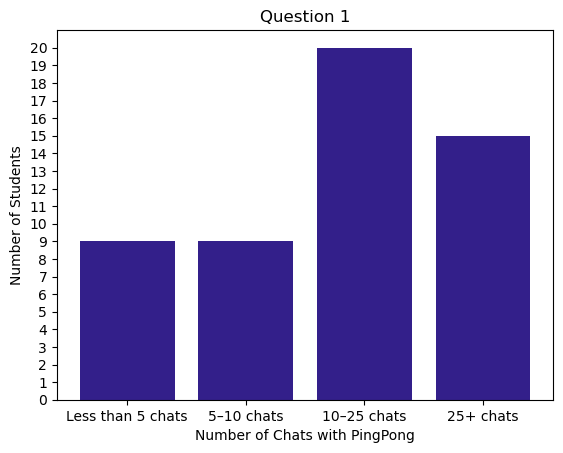

In [7]:
# get unique values
times_used = survey['How many times have you used PingPong, approximately? '].value_counts(sort = False)

# order x-axis
order = ["Less than 5 chats", "5–10 chats", "10–25 chats", "25+ chats"]

# sort times_used by the order
times_used.index = pd.Categorical(times_used.index, categories=order, ordered=True)
times_used = times_used.sort_index()

# graph
plt.bar(x = times_used.index, height = times_used.values, color = color_navy)
plt.xlabel("Number of Chats with PingPong")
plt.ylabel("Number of Students")
plt.title("Question 1")
# adjust y ticks
y_max = max(times_used.values)
plt.yticks(np.arange(0, y_max + 1, 1))  # range: 0 to max value + 1, step of 1

plt.show()

## Question 1 with Proportion

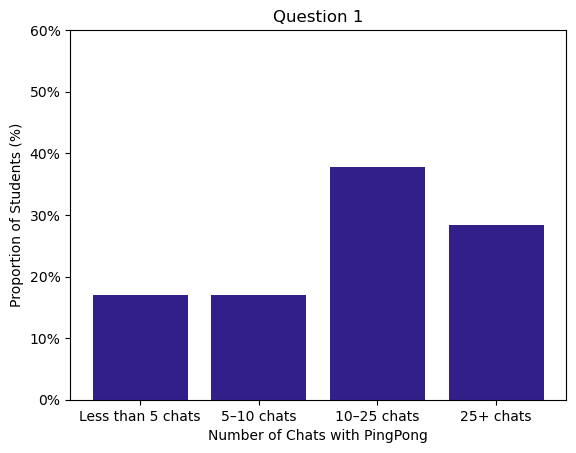

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# get unique values
times_used = survey['How many times have you used PingPong, approximately? '].value_counts(sort=False)

# order x-axis
order = ["Less than 5 chats", "5–10 chats", "10–25 chats", "25+ chats"]

# sort times_used by the order
times_used.index = pd.Categorical(times_used.index, categories=order, ordered=True)
times_used = times_used.sort_index()

# convert counts to proportions
total_responses = times_used.sum()
proportions = times_used / total_responses  # Get proportions

# graph
plt.bar(x=proportions.index, height=proportions.values, color=color_navy)
plt.xlabel("Number of Chats with PingPong")
plt.ylabel("Proportion of Students (%)")
plt.title("Question 1")

# adjust y-axis to have a max of 60%
plt.ylim(0, 0.6)
plt.yticks(np.arange(0, 0.7, 0.1), labels=[f"{int(y*100)}%" for y in np.arange(0, 0.7, 0.1)])

plt.show()

##### Most students have utilized PingPong over 10 times, with only 9 in this sample using it less than 5 times.

## Question 2/3

### 2. Why have you chatted with PingPong less than 5 times? 

### 3. Would you use PingPong more if it were different?

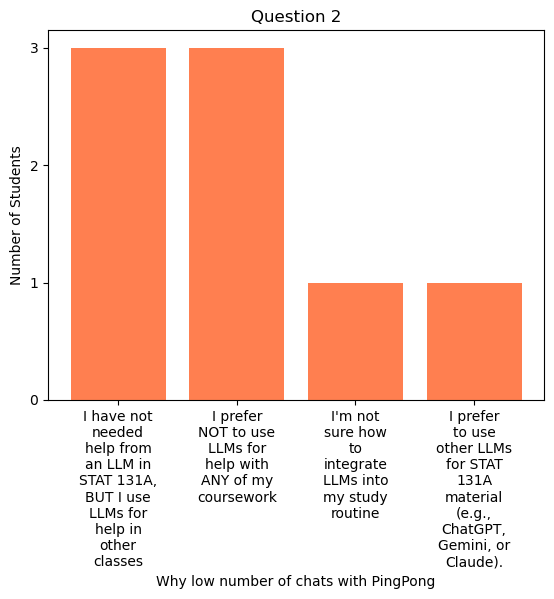

In [9]:
# wraps bar labels
from textwrap import wrap

# get unique values
why_low = survey['Why have you chatted with PingPong less than 5 times?'].value_counts(sort = False)

# Wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in why_low.index]  

# graph
plt.bar(x = wrapped_labels, height = why_low.values, color = color_coral)
plt.xlabel("Why low number of chats with PingPong")
plt.ylabel("Number of Students")
plt.title("Question 2")
# adjust y ticks
y_max = max(why_low.values)
plt.yticks(np.arange(0, y_max + 1, 1))  # range: 0 to max value + 1, step of 1

plt.show()

#### Most students do not need LLMs in this class or prefer not to use them altogether. Only 1 uses other LLMs instead (which is not allowed in this course which may have biased the responses)

## Question 4/5

### 4. If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM? 

### 5. Please elaborate on your response to the previous question.

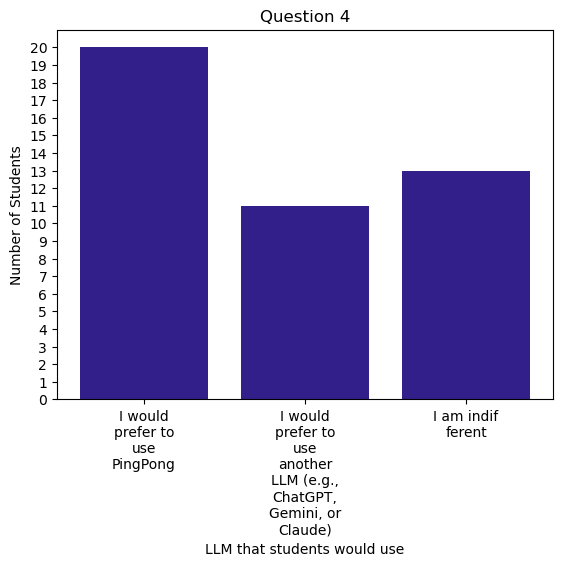

In [10]:
# get unique values
which_llm = survey['If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM?'].value_counts(sort = False)

# Wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in which_llm.index]  

# graph
plt.bar(x = wrapped_labels, height = which_llm.values, color = color_navy)
plt.xlabel("LLM that students would use")
plt.ylabel("Number of Students")
plt.title("Question 4")
# adjust y ticks
y_max = max(which_llm.values)
plt.yticks(np.arange(0, y_max + 1, 1))  # range: 0 to max value + 1, step of 1

plt.show()

### Question 4 with Proportion

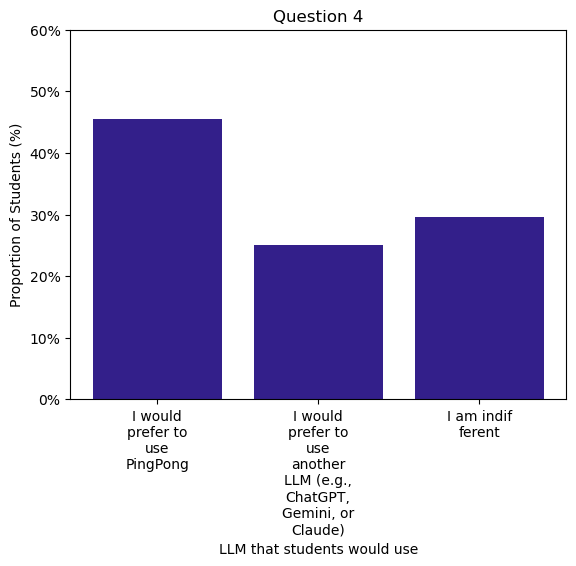

In [11]:
# get unique values
which_llm = survey['If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM?'].value_counts(sort=False)

# convert counts to proportions
total_responses = which_llm.sum()
proportions = which_llm / total_responses  # Get proportions

# Wrap labels for better readability
wrapped_labels = ["\n".join(wrap(label, 10)) for label in proportions.index]  

# graph
plt.bar(x=wrapped_labels, height=proportions.values, color=color_navy)
plt.xlabel("LLM that students would use")
plt.ylabel("Proportion of Students (%)")
plt.title("Question 4")

# adjust y-axis to display percentages
plt.ylim(0, 0.6)  # Set max to 60%
plt.yticks(np.arange(0, 0.7, 0.1), labels=[f"{int(y*100)}%" for y in np.arange(0, 0.7, 0.1)])

plt.show()


### Question 4 Split Into Groups

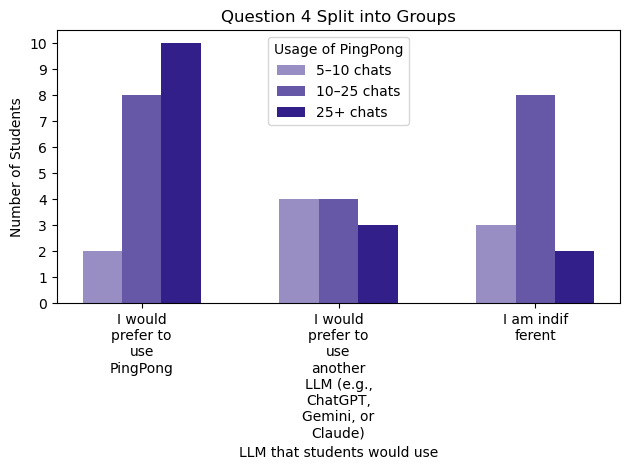

In [12]:
# base color and create a gradient of shades
base_rgba = to_rgba(color_navy)
gradient_colors = [
    (*base_rgba[:3], 0.5),  # lighter shade for 5–10 chats
    (*base_rgba[:3], 0.75),  # medium shade for 10–25 chats
    (*base_rgba[:3], 1.0)    # darkest shade for 25+ chats
]

# order of categories
category_order = [
    "I would prefer to use PingPong",
    "I would prefer to use another LLM (e.g., ChatGPT, Gemini, or Claude)",
    "I am indifferent"
]

# stacked bar chart
# order of the usage categories
usage_order = ['5–10 chats', '10–25 chats', '25+ chats']

# group data
grouped_data = survey.groupby(
    ['If you wanted to learn more about a statistical concept, would you prefer to use PingPong or another LLM?',
     'How many times have you used PingPong, approximately? ']
).size().unstack()

# reorder index to match the desired order of categories
grouped_data = grouped_data.reindex(category_order)

# reorder columns based on order
grouped_data = grouped_data[usage_order]

# wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in grouped_data.index]

# bar positions and width
bar_width = 0.2
x = np.arange(len(wrapped_labels))

# plot each category of 'How many times have you used PingPong, approximately?'
for i, (col, color) in enumerate(zip(grouped_data.columns, gradient_colors)):
    plt.bar(x + i * bar_width, grouped_data[col].fillna(0), width=bar_width, color=color, label=col)

# graph
plt.xticks(x + bar_width * (len(grouped_data.columns) - 1) / 2, wrapped_labels)
plt.xlabel("LLM that students would use")
plt.ylabel("Number of Students")
plt.title("Question 4 Split into Groups")
plt.legend(title='Usage of PingPong')
y_max = grouped_data.max().max()
plt.yticks(np.arange(0, y_max + 1, 1))  # Range: 0 to max value + 1, step of 1

# display
plt.tight_layout()
plt.show()


#### Most student prefer PingPong over other LLMs. With common reasoning being that, despite their annoyance, PingPong forces them to explain understanding and that the professor approved and provided this resource. Futhermore, students with more experience with PingPong (25+ chats) prefer PingPong.

## Question 6/9

### 6. If course staff were not available, what percentage of your questions could PingPong fully answer?

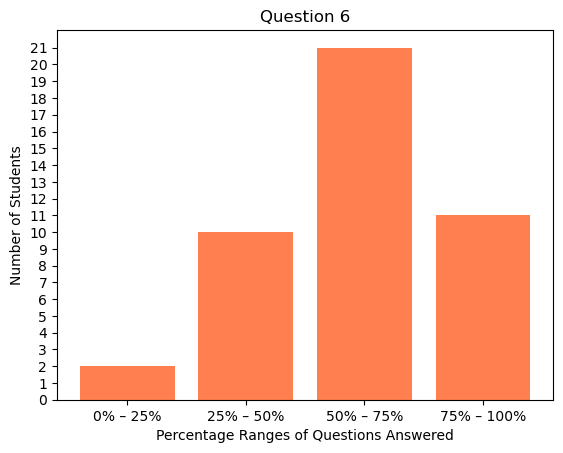

In [13]:
# get unique values
staff_q = survey['If course staff were not available, what percentage of your questions could PingPong fully answer? '].value_counts(sort = False)

# order x-axis
order = ["0% – 25%", "25% – 50%", "50% – 75%", "75% – 100%"]

# sort staff_q by the order
staff_q.index = pd.Categorical(staff_q.index, categories=order, ordered=True)
staff_q = staff_q.sort_index()

# graph
plt.bar(x = staff_q.index, height = staff_q.values, color = color_coral)
plt.xlabel("Percentage Ranges of Questions Answered")
plt.ylabel("Number of Students")
plt.title("Question 6")

# adjust y ticks
y_max = max(staff_q.values)
plt.yticks(np.arange(0, y_max + 1, 1))  # range: 0 to max value + 1, step of 1

plt.show()

### Question 6 with Proportions

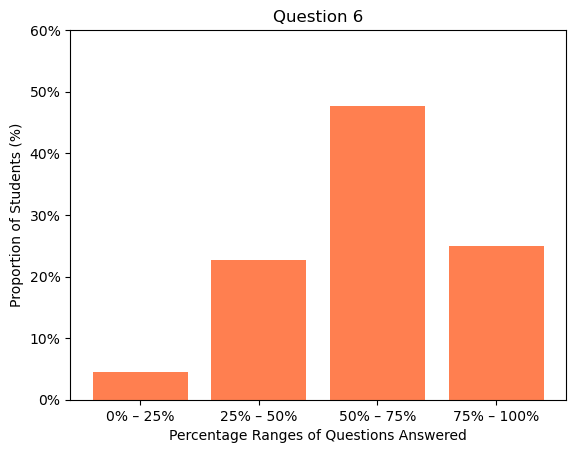

In [14]:
# get unique values
staff_q = survey['If course staff were not available, what percentage of your questions could PingPong fully answer? '].value_counts(sort=False)

# order x-axis
order = ["0% – 25%", "25% – 50%", "50% – 75%", "75% – 100%"]

# sort staff_q by the order
staff_q.index = pd.Categorical(staff_q.index, categories=order, ordered=True)
staff_q = staff_q.sort_index()

# convert counts to proportions
total_responses = staff_q.sum()
proportions = staff_q / total_responses  # Get proportions

# graph
plt.bar(x=proportions.index, height=proportions.values, color=color_coral)
plt.xlabel("Percentage Ranges of Questions Answered")
plt.ylabel("Proportion of Students (%)")
plt.title("Question 6")

# adjust y-axis to display percentages
plt.ylim(0, 0.6)  # Set max to 60%
plt.yticks(np.arange(0, 0.7, 0.1), labels=[f"{int(y*100)}%" for y in np.arange(0, 0.7, 0.1)])

plt.show()


### Split Q6 into groups

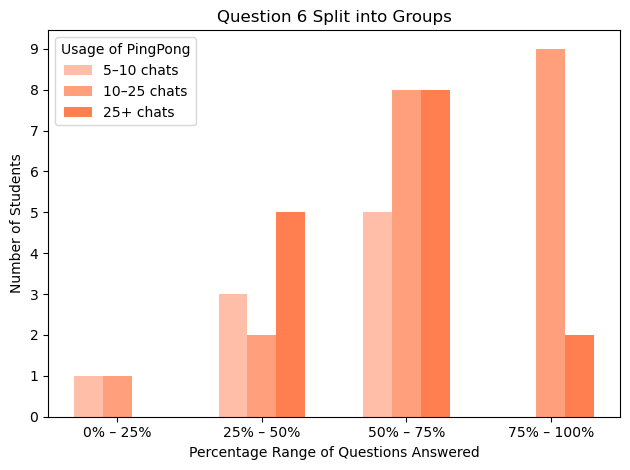

In [15]:
# base color and create a gradient of shades
base_rgba = to_rgba(color_coral)
gradient_colors = [
    (*base_rgba[:3], 0.5),  # lighter shade for 5–10 chats
    (*base_rgba[:3], 0.75),  # medium shade for 10–25 chats
    (*base_rgba[:3], 1.0)    # darkest shade for 25+ chats
]

# order of categories
category_order = ["0% – 25%", "25% – 50%", "50% – 75%", "75% – 100%"]

# stacked bar chart
# order of the usage categories
usage_order = ['5–10 chats', '10–25 chats', '25+ chats']

# group data
grouped_data = survey.groupby(
    ['If course staff were not available, what percentage of your questions could PingPong fully answer? ', 'How many times have you used PingPong, approximately? ']).size().unstack()

# reorder index to match the desired order of categories
grouped_data = grouped_data.reindex(category_order)

# reorder columns based on order
grouped_data = grouped_data[usage_order]

# wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in grouped_data.index]

# bar positions and width
bar_width = 0.2
x = np.arange(len(wrapped_labels))

# plot each category of 'How many times have you used PingPong, approximately?'
for i, (col, color) in enumerate(zip(grouped_data.columns, gradient_colors)):
    plt.bar(x + i * bar_width, grouped_data[col].fillna(0), width=bar_width, color=color, label=col)

# graph
plt.xticks(x + bar_width * (len(grouped_data.columns) - 1) / 2, wrapped_labels)
plt.xlabel("Percentage Range of Questions Answered")
plt.ylabel("Number of Students")
plt.title("Question 6 Split into Groups")
plt.legend(title='Usage of PingPong')
y_max = np.nanmax(grouped_data.values)
y_max_int = int(np.ceil(y_max))
plt.yticks(np.arange(0, y_max + 1, 1))  # Range: 0 to max value + 1, step of 1

# display
plt.tight_layout()
plt.show()

#### Here we can see that students that use PingPong a lot (25+ chats) do not necessarily use it a lot because it can answer most of their questions. I seems to be that students with 25+ chats just tend to have a lot of questions or interest in the course and the vast majority of this group still have to have 25-50% of their questions answered by course staff. However, an interesting group here is the 10-25 chat group who, by large majority, have over 50% of their questions answered by PingPong. Maybe these students are less invested into learning and once they get an answer from PingPong their are satisfied? Interesting patterns overall.

### 9. Without access to LLMs, I would attend STAT 131A office hours...

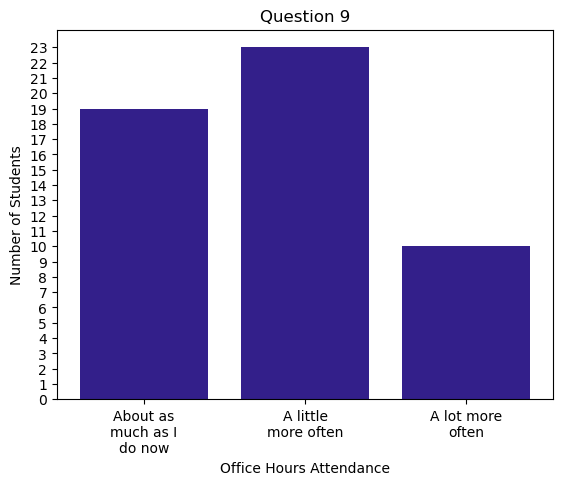

In [16]:
# get unique values
office_hrs = survey['Without access to LLMs, I would attend STAT 131A office hours...'].value_counts(sort = False)

# order x-axis
order = ["About as much as I do now", "A little more often", "A lot more often"]

# sort staff_q by the order
office_hrs.index = pd.Categorical(office_hrs.index, categories=order, ordered=True)
office_hrs = office_hrs.sort_index()

# Wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in office_hrs.index]  

# graph
plt.bar(x = wrapped_labels, height = office_hrs.values, color = color_navy)
plt.xlabel("Office Hours Attendance")
plt.ylabel("Number of Students")
plt.title("Question 9")

# adjust y ticks
y_max = max(office_hrs.values)
plt.yticks(np.arange(0, y_max + 1, 1))  # range: 0 to max value + 1, step of 1

plt.show()

#### Here we can definitely see the arguably negative consequences of LLM tutors: less usage of tutors which may contribute to making tutors obsolete. However, in much larger classes at Berkeley, office hours waiting times can be upwards of an hour, so they may help with the current resources given by focusing office hours energy on more complex questions. If the school continues to limit budget for tutoring, then LLMs tutors is the best way to make education more accessible.

### Question 9 with Proportions 

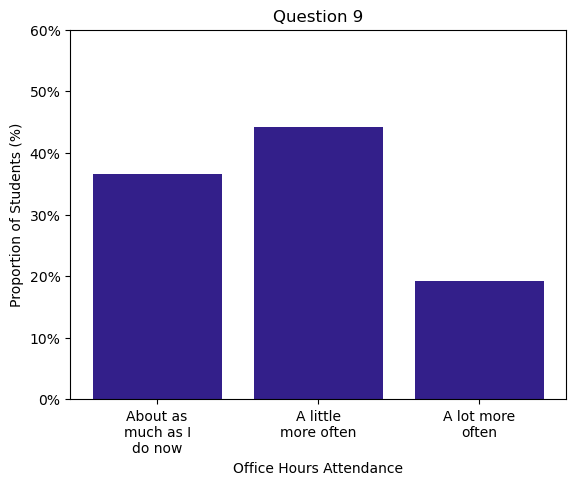

In [17]:
# get unique values
office_hrs = survey['Without access to LLMs, I would attend STAT 131A office hours...'].value_counts(sort=False)

# order x-axis
order = ["About as much as I do now", "A little more often", "A lot more often"]

# sort office_hrs by the order
office_hrs.index = pd.Categorical(office_hrs.index, categories=order, ordered=True)
office_hrs = office_hrs.sort_index()

# convert counts to proportions
total_responses = office_hrs.sum()
proportions = office_hrs / total_responses  # Get proportions

# Wrap labels for better readability
wrapped_labels = ["\n".join(wrap(label, 10)) for label in proportions.index]  

# graph
plt.bar(x=wrapped_labels, height=proportions.values, color=color_navy)
plt.xlabel("Office Hours Attendance")
plt.ylabel("Proportion of Students (%)")
plt.title("Question 9")

# adjust y-axis to display percentages
plt.ylim(0, 0.6)  # Set max to 60%
plt.yticks(np.arange(0, 0.7, 0.1), labels=[f"{int(y*100)}%" for y in np.arange(0, 0.7, 0.1)])

plt.show()

### Split Q9 into groups

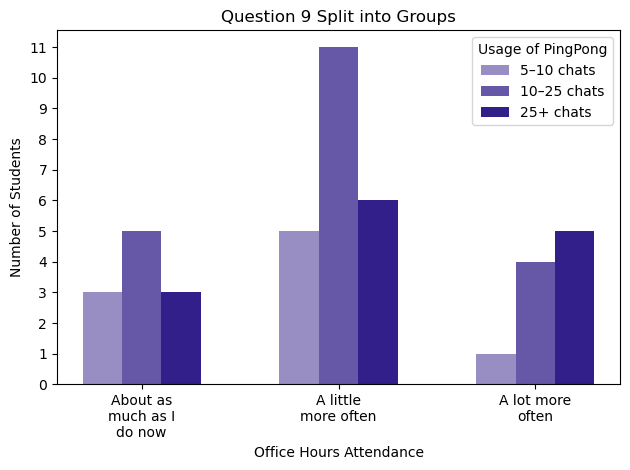

In [18]:
# base color and create a gradient of shades
base_rgba = to_rgba(color_navy)
gradient_colors = [
    (*base_rgba[:3], 0.5),  # lighter shade for 5–10 chats
    (*base_rgba[:3], 0.75),  # medium shade for 10–25 chats
    (*base_rgba[:3], 1.0)    # darkest shade for 25+ chats
]

# order of categories
category_order = ["About as much as I do now", "A little more often", "A lot more often"]

# stacked bar chart
# order of the usage categories
usage_order = ['5–10 chats', '10–25 chats', '25+ chats']

# group data
grouped_data = survey.groupby(
    ['Without access to LLMs, I would attend STAT 131A office hours...', 'How many times have you used PingPong, approximately? ']).size().unstack()

# reorder index to match the desired order of categories
grouped_data = grouped_data.reindex(category_order)

# reorder columns based on order
grouped_data = grouped_data[usage_order]

# wrap labels
wrapped_labels = ["\n".join(wrap(label, 10)) for label in grouped_data.index]

# bar positions and width
bar_width = 0.2
x = np.arange(len(wrapped_labels))

# plot each category of 'How many times have you used PingPong, approximately?'
for i, (col, color) in enumerate(zip(grouped_data.columns, gradient_colors)):
    plt.bar(x + i * bar_width, grouped_data[col].fillna(0), width=bar_width, color=color, label=col)

# graph
plt.xticks(x + bar_width * (len(grouped_data.columns) - 1) / 2, wrapped_labels)
plt.xlabel("Office Hours Attendance")
plt.ylabel("Number of Students")
plt.title("Question 9 Split into Groups")
plt.legend(title='Usage of PingPong')
y_max = np.nanmax(grouped_data.values)
y_max_int = int(np.ceil(y_max))
plt.yticks(np.arange(0, y_max + 1, 1))  # Range: 0 to max value + 1, step of 1

# display
plt.tight_layout()
plt.show()


#### Here shows that moderate to high PingPong usage has a correlation with less office hours attendance. As well as low PingPong usage users rarely saying that they would go to office hours a lot more often. This makes logical sense, and would happen regardless due to LLMs being widely available. I think a way to combatting low office hours attendance, as thought by Josh, is to rephrase office hours as “group tutoring”. This lowers the intimidation that students have, whether that be needing to have a “good” question ready, being alone with the professor, or admitting their weaknesses in the course.

## Question 10

#### Without LLMs, do you think your understanding of the STAT 131A material would be different? 

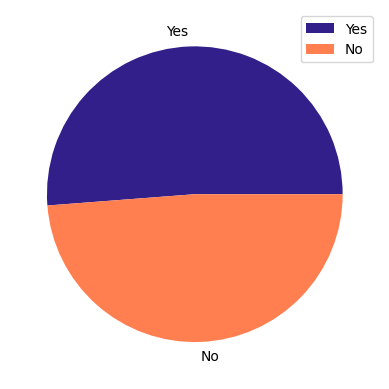

In [19]:
# VALUES DETERMINED BY LOOKING AT EACH RESPONSE IN SURVEY
y = np.array([21,20])
y_n_labels = ["Yes", "No"]
colors_pie = []
colors_pie.append(color_navy)
colors_pie.append(color_coral)
plt.pie(y, labels = y_n_labels, colors = colors_pie)
plt.legend()
plt.show()

Slight majority for Yes

## Question 11

#### Without LLMs, do think your homework and exam grades in STAT 131A would be different?

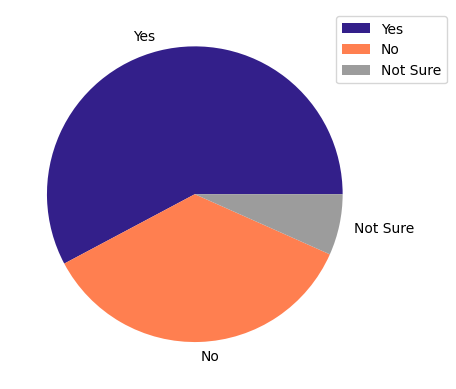

In [20]:
# VALUES DETERMINED BY LOOKING AT EACH RESPONSE IN SURVEY
y = np.array([26,16,3])
y_n_labels = ["Yes", "No", "Not Sure"]
colors_pie = []
colors_pie.append(color_navy)
colors_pie.append(color_coral)
colors_pie.append("#9c9c9c")
plt.pie(y, labels = y_n_labels, colors = colors_pie)
plt.legend(y_n_labels, loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

### Question 11 bar chart

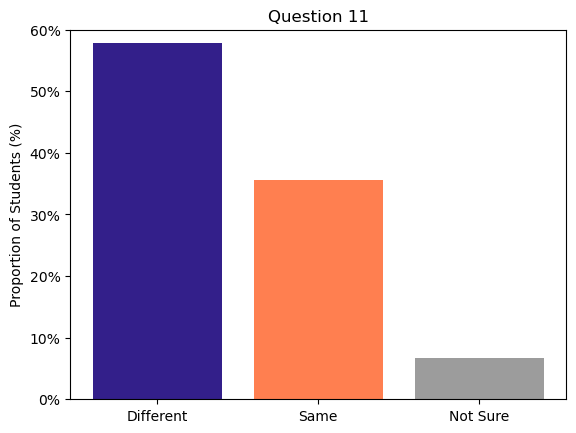

In [21]:
# VALUES DETERMINED BY LOOKING AT EACH RESPONSE IN SURVEY
y = np.array([26, 16, 3])
y_n_labels = ["Different", "Same", "Not Sure"]
colors_bar = [color_navy, color_coral, "#9c9c9c"]  # Use the same colors as before

# Convert counts to proportions
total_responses = np.sum(y)
proportions = y / total_responses  # Get proportions

# Create bar chart
plt.bar(y_n_labels, proportions, color=colors_bar)

# Labels and title
# plt.xlabel("Response")
plt.ylabel("Proportion of Students (%)")
plt.title("Question 11")

# Adjust y-axis to display percentages
plt.ylim(0, 0.6)  # Set max to 60%
plt.yticks(np.arange(0, 0.7, 0.1), labels=[f"{int(y*100)}%" for y in np.arange(0, 0.7, 0.1)])

plt.show()

#### Majority for yes my grade WOULD change

## Question 12

#### Which of the following would you prefer?
#### 1. Programming+statistics courses allow students to use any LLM for homework help.
#### 2. Programming+statistics courses only allow customized chatbots, similar to PingPong.
#### 3. Programming+statistics courses do not allow students to use any LLM.

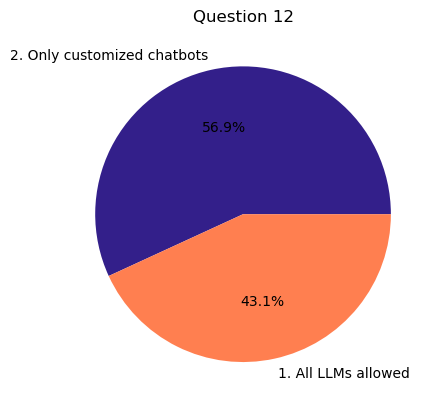

In [24]:
y = survey["Which of the following would you prefer?\n\n1. Programming+statistics courses allow students to use any LLM for homework help.\n\n2. Programming+statistics courses only allow customized chatbots, similar to PingPong.\n\n3. Programming+statistics courses do not allow students to use any LLM.\n"].value_counts()
mycolors = ["#331f8aff", "#ff7f50ff", "#85c1e9ff"]  # Add a color for the third option

# pie chart
plt.pie(y.values, labels=y.index, colors=mycolors[:len(y)], autopct='%1.1f%%')

# three options for the legend
legend_labels = [
    "1. All LLMs allowed.",
    "2. Only customized chatbots.",
    "3. No LLMs at all."
]

#show
plt.title("Question 12")
plt.show()


#### Notice how no one choose that LLMs should not be allowed at all.

## Question 13

#### Please elaborate on your response to the previous question. Why do you prefer your chosen option?

#### Customization to course importance. Surprisingly these students are in the minority. This is quite contradictory to prior sentiments of being thankful that PingPong actually tutors the student and how they like that it is catered towards the course. The students that feel that all LLMs should be allow bring up really good points, and they are the majority. The real world has no restrictions on LLM usage and if there is respect to academic honesty who are we to manage it? 